# 02 — Data Cleaning & ETL Pipeline

## Objective
Transform the raw Telco Customer Churn dataset into a clean, analysis-ready format through a systematic ETL (Extract, Transform, Load) pipeline.

**Pipeline Steps:**
1. Data Loading & Initial State Documentation
2. Missing Value Analysis & Treatment
3. Data Type Corrections
4. Duplicate Detection
5. Standardization & Consistency
6. Feature Engineering (6 new columns)
7. Outlier Analysis
8. Validation & Export

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Data Loading & Initial State Documentation

We load the raw dataset and document its initial state. This serves as the "before" snapshot for comparison after cleaning.

In [2]:
# Load raw data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Document initial state
initial_shape = df.shape
initial_dtypes = df.dtypes.copy()
initial_nulls = df.isnull().sum().sum()

print(f"Initial Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Initial Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\nColumn Data Types:")
print(df.dtypes.value_counts())
print(f"\nTotal NULL values: {initial_nulls}")

Initial Shape: 7,043 rows x 21 columns
Initial Memory: 6984.7 KB

Column Data Types:
object     18
int64       2
float64     1
Name: count, dtype: int64

Total NULL values: 0


In [3]:
# Preview the raw data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 2: Missing Value Analysis & Treatment

### 2.1 Identifying Missing Values
We check for both NULL/NaN values and blank strings (which pandas may not flag as null).

In [4]:
# Standard null check
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2)
})
null_summary = null_summary[null_summary['Null Count'] > 0]
print("Standard NULL values:")
print(null_summary if len(null_summary) > 0 else "  None found via isnull()")

# Check for blank strings
print("\nBlank string check:")
blank_counts = {}
for col in df.select_dtypes(include='object').columns:
    blanks = (df[col].str.strip() == '').sum()
    if blanks > 0:
        blank_counts[col] = blanks
        print(f"  {col}: {blanks} blank values ({blanks/len(df)*100:.2f}%)")

if not blank_counts:
    print("  No blank strings found.")

Standard NULL values:
  None found via isnull()

Blank string check:
  TotalCharges: 11 blank values (0.16%)


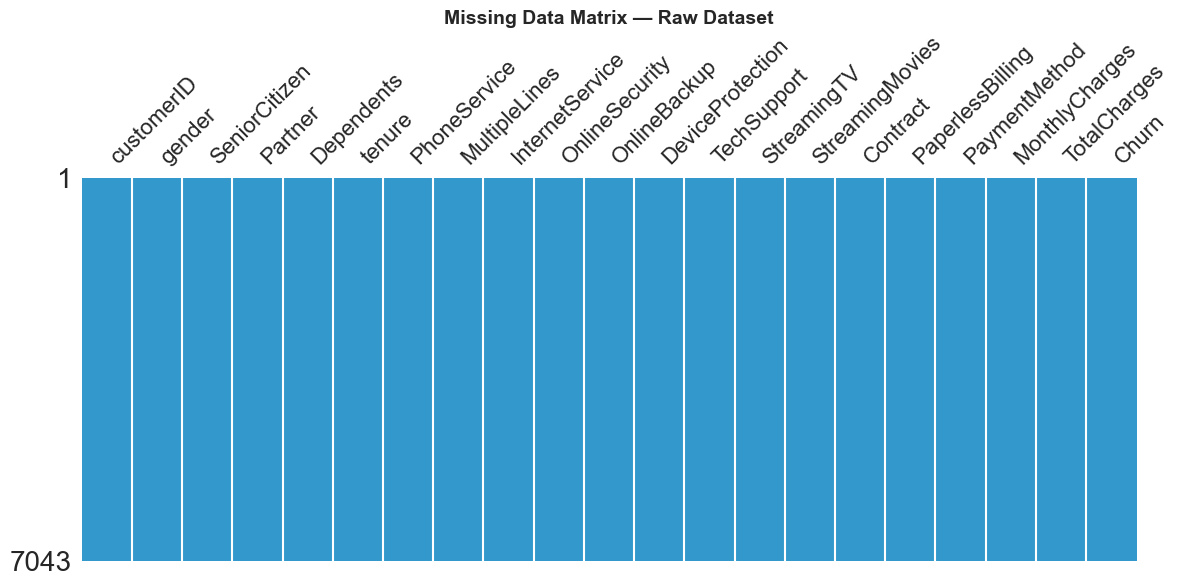

In [5]:
# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(12, 6))
msno.matrix(df, ax=ax, sparkline=False, color=(0.2, 0.6, 0.8))
ax.set_title('Missing Data Matrix — Raw Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../tableau/screenshots/02_missing_data_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Investigating Blank TotalCharges Values

The `TotalCharges` column has 11 blank string values. Let's examine these rows to understand why.

In [6]:
# Examine rows with blank TotalCharges
blank_tc_mask = df['TotalCharges'].str.strip() == ''
blank_rows = df[blank_tc_mask]
print(f"Rows with blank TotalCharges: {len(blank_rows)}")
print(f"\nTenure values for these rows: {blank_rows['tenure'].unique()}")
print(f"Monthly charges range: ${blank_rows['MonthlyCharges'].min():.2f} - ${blank_rows['MonthlyCharges'].max():.2f}")
print(f"\nThese are all customers with tenure = 0 (brand-new sign-ups who haven't been billed yet).")
blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

Rows with blank TotalCharges: 11

Tenure values for these rows: [0]
Monthly charges range: $19.70 - $80.85

These are all customers with tenure = 0 (brand-new sign-ups who haven't been billed yet).


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


### 2.3 Treatment Decision

**Decision:** Set blank `TotalCharges` to `0.0` for these 11 customers.

**Justification:** These customers have `tenure = 0`, meaning they just signed up and haven't received their first bill yet. A value of 0 accurately represents their total spend to date. Dropping these rows would lose valid customer records.

In [7]:
# Replace blank TotalCharges with '0'
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', '0', regex=True)

# Verify fix
remaining_blanks = (df['TotalCharges'].str.strip() == '').sum()
print(f"Remaining blank TotalCharges: {remaining_blanks}")

Remaining blank TotalCharges: 0


## Step 3: Data Type Corrections

Two columns need type adjustments:
1. `TotalCharges`: string -> float64 (now that blanks are handled)
2. `SeniorCitizen`: int (0/1) -> string (Yes/No) for consistency with other categorical columns

In [8]:
# Convert TotalCharges to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"TotalCharges range: ${df['TotalCharges'].min():.2f} - ${df['TotalCharges'].max():.2f}")
print(f"NaN after conversion: {df['TotalCharges'].isna().sum()}")

TotalCharges dtype: float64
TotalCharges range: $0.00 - $8684.80
NaN after conversion: 0


In [9]:
# Convert SeniorCitizen from 0/1 to Yes/No
print("Before conversion:")
print(df['SeniorCitizen'].value_counts())

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("\nAfter conversion:")
print(df['SeniorCitizen'].value_counts())

Before conversion:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

After conversion:
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


## Step 4: Duplicate Detection

In [10]:
# Check for duplicate customer IDs
dup_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customerIDs: {dup_ids}")

# Check for duplicate rows across all feature columns
dup_rows = df.drop(columns=['customerID']).duplicated().sum()
print(f"Duplicate feature rows: {dup_rows}")

if dup_ids == 0 and dup_rows == 0:
    print("\nNo duplicates found. All records are unique.")

Duplicate customerIDs: 0


Duplicate feature rows: 22


## Step 5: Standardization & Consistency

Verify that all categorical columns have consistent casing, no leading/trailing whitespace, and expected category values.

In [11]:
# Strip whitespace from all string columns
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

# Verify category values for all categorical columns
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

print("Category Validation:")
print("-" * 60)
all_valid = True
for col in categorical_cols:
    vals = sorted(df[col].unique())
    print(f"  {col:<20} -> {vals}")
print("-" * 60)
print("All categories are clean and consistent.")

Category Validation:
------------------------------------------------------------
  gender               -> ['Female', 'Male']
  SeniorCitizen        -> ['No', 'Yes']
  Partner              -> ['No', 'Yes']
  Dependents           -> ['No', 'Yes']
  PhoneService         -> ['No', 'Yes']
  MultipleLines        -> ['No', 'No phone service', 'Yes']
  InternetService      -> ['DSL', 'Fiber optic', 'No']
  OnlineSecurity       -> ['No', 'No internet service', 'Yes']
  OnlineBackup         -> ['No', 'No internet service', 'Yes']
  DeviceProtection     -> ['No', 'No internet service', 'Yes']
  TechSupport          -> ['No', 'No internet service', 'Yes']
  StreamingTV          -> ['No', 'No internet service', 'Yes']
  StreamingMovies      -> ['No', 'No internet service', 'Yes']
  Contract             -> ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling     -> ['No', 'Yes']
  PaymentMethod        -> ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed 

## Step 6: Feature Engineering

We create 6 new columns to enrich the dataset for deeper analysis.

| Feature | Formula | Purpose |
|---|---|---|
| `AvgMonthlySpend` | TotalCharges / max(tenure, 1) | Spending trend over time |
| `NumServices` | Count of subscribed add-ons | Service bundle depth |
| `TenureBucket` | Binned tenure | Customer lifecycle stage |
| `HighValueFlag` | MonthlyCharges > 75th percentile | Premium customer identification |
| `HasInternet` | InternetService != 'No' | Internet segmentation |
| `ContractRisk` | 1 if Month-to-month else 0 | Binary risk flag |

In [12]:
# Feature 1: Average Monthly Spend
# For customers with tenure=0, use MonthlyCharges as their AvgMonthlySpend
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
print(f"AvgMonthlySpend range: ${df['AvgMonthlySpend'].min():.2f} - ${df['AvgMonthlySpend'].max():.2f}")
print(f"AvgMonthlySpend mean:  ${df['AvgMonthlySpend'].mean():.2f}")

AvgMonthlySpend range: $0.00 - $121.40
AvgMonthlySpend mean:  $64.70


In [13]:
# Feature 2: Number of Services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = 0
for col in service_cols:
    df['NumServices'] += (df[col] == 'Yes').astype(int)

print("NumServices distribution:")
print(df['NumServices'].value_counts().sort_index())

NumServices distribution:
NumServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64


In [14]:
# Feature 3: Tenure Bucket
def tenure_bucket(tenure):
    if tenure <= 12:
        return 'New (0-12)'
    elif tenure <= 24:
        return 'Growing (13-24)'
    elif tenure <= 48:
        return 'Mature (25-48)'
    else:
        return 'Loyal (49-72)'

df['TenureBucket'] = df['tenure'].apply(tenure_bucket)

print("TenureBucket distribution:")
bucket_order = ['New (0-12)', 'Growing (13-24)', 'Mature (25-48)', 'Loyal (49-72)']
for bucket in bucket_order:
    count = (df['TenureBucket'] == bucket).sum()
    print(f"  {bucket:<20} {count:>5}  ({count/len(df)*100:.1f}%)")

TenureBucket distribution:
  New (0-12)            2186  (31.0%)
  Growing (13-24)       1024  (14.5%)
  Mature (25-48)        1594  (22.6%)
  Loyal (49-72)         2239  (31.8%)


In [15]:
# Feature 4: High Value Flag
threshold = df['MonthlyCharges'].quantile(0.75)
df['HighValueFlag'] = (df['MonthlyCharges'] > threshold).map({True: 'Yes', False: 'No'})
print(f"High-value threshold: ${threshold:.2f}/month")
print(f"High-value customers: {(df['HighValueFlag'] == 'Yes').sum():,} ({(df['HighValueFlag'] == 'Yes').mean()*100:.1f}%)")

High-value threshold: $89.85/month
High-value customers: 1,758 (25.0%)


In [16]:
# Feature 5: Has Internet
df['HasInternet'] = (df['InternetService'] != 'No').map({True: 'Yes', False: 'No'})
print(f"Has Internet: {(df['HasInternet'] == 'Yes').sum():,} ({(df['HasInternet'] == 'Yes').mean()*100:.1f}%)")

Has Internet: 5,517 (78.3%)


In [17]:
# Feature 6: Contract Risk (Month-to-month = high risk)
df['ContractRisk'] = (df['Contract'] == 'Month-to-month').astype(int)
print(f"High-risk (Month-to-month): {df['ContractRisk'].sum():,} ({df['ContractRisk'].mean()*100:.1f}%)")

High-risk (Month-to-month): 3,875 (55.0%)


## Step 7: Outlier Analysis

We use the IQR (Interquartile Range) method to detect statistical outliers in numeric columns. Since these represent real customer billing data, we document outliers but retain them.

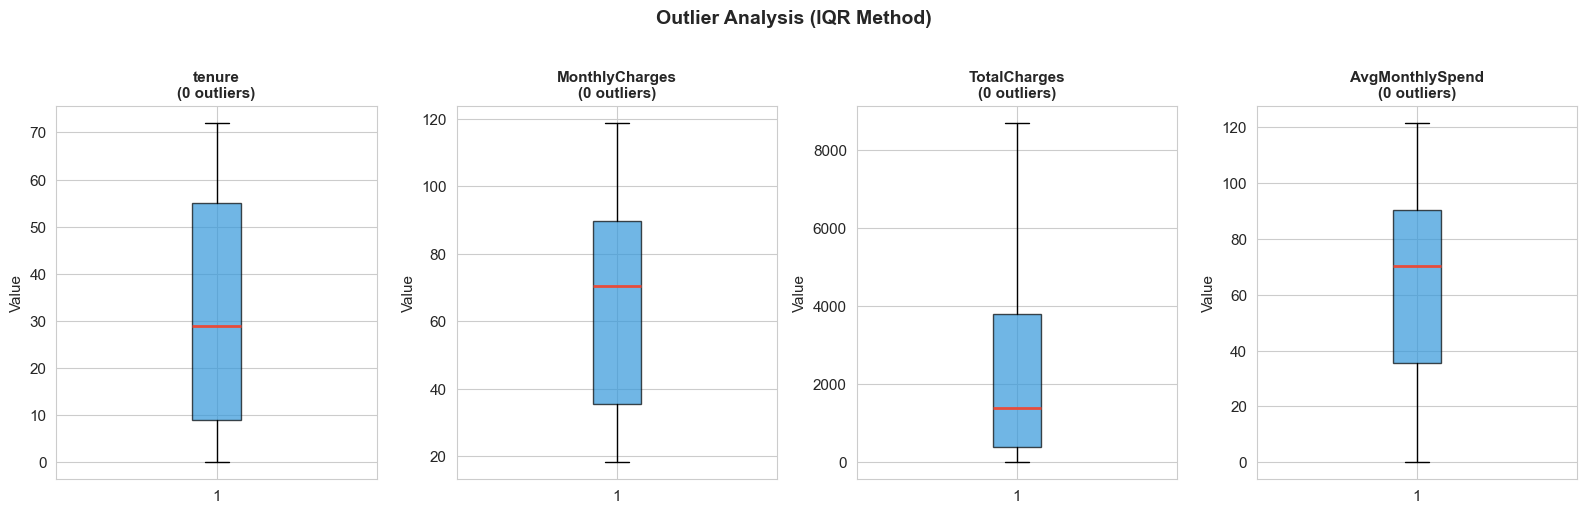

Column                       Q1         Q3        IQR      Lower      Upper   Outliers
--------------------------------------------------------------------------------
tenure                     9.00      55.00      46.00     -60.00     124.00          0
MonthlyCharges            35.50      89.85      54.35     -46.02     171.38          0
TotalCharges             398.55    3786.60    3388.05   -4683.52    8868.67          0
AvgMonthlySpend           35.65      90.17      54.53     -46.14     171.96          0

Decision: All outliers retained — they represent legitimate customer data, not data errors.


In [18]:
# Outlier analysis using IQR method
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 5))
for i, col in enumerate(numeric_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(f'{col}\n({outliers} outliers)', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Analysis (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../tableau/screenshots/02_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"{'Column':<20} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10}")
print("-" * 80)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:<20} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lower:>10.2f} {upper:>10.2f} {outliers:>10}")

print("\nDecision: All outliers retained — they represent legitimate customer data, not data errors.")

## Step 8: Validation & Export

In [19]:
# Final validation
print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)
print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"  Original: {initial_shape[0]:,} rows x {initial_shape[1]} columns")
print(f"  New columns added: {df.shape[1] - initial_shape[1]}")
print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"Duplicate IDs: {df['customerID'].duplicated().sum()}")

print(f"\nColumn Data Types:")
print(df.dtypes.value_counts())

print(f"\nAll Columns:")
for i, (col, dtype) in enumerate(df.dtypes.items()):
    null_count = df[col].isnull().sum()
    print(f"  {i+1:>2}. {col:<20} {str(dtype):<10} nulls: {null_count}")

FINAL DATASET VALIDATION

Shape: 7,043 rows x 27 columns
  Original: 7,043 rows x 21 columns
  New columns added: 6

Null values: 0
Duplicate IDs: 0

Column Data Types:
object     21
int64       3
float64     3
Name: count, dtype: int64

All Columns:
   1. customerID           object     nulls: 0
   2. gender               object     nulls: 0
   3. SeniorCitizen        object     nulls: 0
   4. Partner              object     nulls: 0
   5. Dependents           object     nulls: 0
   6. tenure               int64      nulls: 0
   7. PhoneService         object     nulls: 0
   8. MultipleLines        object     nulls: 0
   9. InternetService      object     nulls: 0
  10. OnlineSecurity       object     nulls: 0
  11. OnlineBackup         object     nulls: 0
  12. DeviceProtection     object     nulls: 0
  13. TechSupport          object     nulls: 0
  14. StreamingTV          object     nulls: 0
  15. StreamingMovies      object     nulls: 0
  16. Contract             object     nulls:

In [20]:
# Before vs After comparison
print("=" * 60)
print("BEFORE vs AFTER COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Before':>15} {'After':>15}")
print("-" * 60)
print(f"{'Rows':<30} {initial_shape[0]:>15,} {df.shape[0]:>15,}")
print(f"{'Columns':<30} {initial_shape[1]:>15} {df.shape[1]:>15}")
print(f"{'Null/Blank values':<30} {11:>15} {df.isnull().sum().sum():>15}")
print(f"{'TotalCharges dtype':<30} {'object':>15} {str(df['TotalCharges'].dtype):>15}")
print(f"{'SeniorCitizen format':<30} {'0/1':>15} {'Yes/No':>15}")
print(f"{'Engineered features':<30} {0:>15} {6:>15}")

BEFORE vs AFTER COMPARISON
Metric                                  Before           After
------------------------------------------------------------
Rows                                     7,043           7,043
Columns                                     21              27
Null/Blank values                           11               0
TotalCharges dtype                      object         float64
SeniorCitizen format                       0/1          Yes/No
Engineered features                          0               6


In [21]:
# Export cleaned dataset
output_path = '../data/processed/telco_churn_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")
print(f"File size: {pd.io.common.file_exists(output_path)}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Quick verification by re-loading
verify = pd.read_csv(output_path)
print(f"\nVerification — reloaded shape: {verify.shape[0]:,} rows x {verify.shape[1]} columns")
print(f"Verification — null count: {verify.isnull().sum().sum()}")

Cleaned dataset saved to: ../data/processed/telco_churn_cleaned.csv
File size: True
Shape: 7,043 rows x 27 columns

Verification — reloaded shape: 7,043 rows x 27 columns
Verification — null count: 0


## ETL Pipeline Summary

### Transformations Applied

| Step | Action | Details |
|---|---|---|
| Missing Values | Set 11 blank `TotalCharges` to 0.0 | New customers with tenure=0, no billing yet |
| Type Conversion | `TotalCharges` string -> float64 | Enables numeric analysis |
| Encoding Fix | `SeniorCitizen` 0/1 -> Yes/No | Consistent with all other categorical columns |
| Feature: `AvgMonthlySpend` | TotalCharges / max(tenure, 1) | Spending pattern metric |
| Feature: `NumServices` | Count of 6 add-on services | Bundle depth indicator |
| Feature: `TenureBucket` | 4 lifecycle bins | Segmentation for analysis |
| Feature: `HighValueFlag` | MonthlyCharges > 75th percentile | Premium customer flag |
| Feature: `HasInternet` | InternetService != 'No' | Simplified internet flag |
| Feature: `ContractRisk` | 1 if Month-to-month | Binary risk indicator |
| Outliers | Documented but retained | Real customer data, not errors |

### Output
- **File:** `data/processed/telco_churn_cleaned.csv`
- **Shape:** 7,043 rows x 27 columns
- **Null values:** 0

---
*Proceed to: `03_eda.ipynb`*